<h1 align="center">
  <span style="color: purple;"> Baseline Models </span>
</h1>

### Table of contents

[1. Overview](#1) <br>
[2. Setup](#2) <br>
[3. Helper Functions](#3) <br>
[4. Baseline Models](#4) <br>
    &emsp;&emsp; [4.1. Z-score](#4.1) <br>
    &emsp;&emsp; [4.2. Multivariate Gaussian](#4.2) <br>
    &emsp;&emsp; [4.3. Gaussian Mixture Models](#4.3) <br>
[5. Results Analysis](#5) <br>


<a id="1"></a>
<h2 align="center">
  <span style="color: #440E03;">1. Overview </span>
</h2>

This notebook establishes simple, interpretable baseline methods for the server anomaly detection task.

The purpose of these baselines is not to build production-ready model components, but to establish reference points against which the more sophisticated models developed later in the project can be evaluated.

The baseline methods focus on simple statistical approaches that require little modeling complexity, such as:

- univariate z-score detection
- multivariate Gaussian modeling
- Gaussian Mixture Models (GMM)


These methods provide different reference points for understanding how much additional value is obtained from more complex reconstruction-based and sequence models.

**Evaluation setup**

The project treats the server measurements as sequential data rather than as independent observations.

Because the final modeling pipeline uses temporal windows, the baselines will also operate on the same windowed representation. This is important for a fair comparison with the models introduced later in the project, particularly the Transformer-based models.

The general data flow is therefore:

```
Raw sequential data
        │
        ▼
Preprocessing
        │
        ▼
Windowing
        │
        ▼
Window representation
        │
        ├──────────────► Statistical baselines
        │
        └──────────────► Neural / sequence models
```


Using the same windowing scheme means that differences in performance are less likely to come simply from giving different models different representations of the data.

For this project, the baseline experiments therefore use the same:

- preprocessing assumptions
- validation data
- window-level anomaly-labeling policy
- evaluation metrics

as the subsequent models whenever the corresponding concept applies.

**Why keep the baselines in the notebook?**

The main project pipeline uses Hydra configuration, model entries, registries, experiment management, MLflow tracking, and other infrastructure intended for reusable ML components.

That infrastructure is valuable for the main models, but applying the same architecture to every simple statistical baseline would add complexity without providing much benefit.

The baselines are therefore implemented directly in this notebook.

This keeps the distinction clear:

- Baselines
    - Simple methods used primarily to establish reference performance.
- Main models
    - Reusable models integrated into the project's standardized training, inference, configuration, and experiment infrastructure.

The notebook should nevertheless use the same data preparation and evaluation conventions as the main pipeline. The simplification is in the model implementation and experiment configuration, not in the experimental methodology.

**Baseline philosophy**

Each baseline answers a slightly different question:

| Baseline | Main question |
|----------|---------------|
| **Z-score** | Can simple univariate deviations detect the anomalies? |
| **Gaussian** | Can the data be modeled as a single multivariate Gaussian distribution? ? |
| **GMM** | Does a mixture of normal regimes describe the data better than one Gaussian? |

These methods establish progressively different assumptions about the structure of the normal data.

The goal is not to optimize every baseline extensively. Instead, they provide credible reference points that help interpret the results of the more complex models.

**Windowing and fair comparison**

A key design decision in this project is the use of temporal windows.

For a window size (W) and stride (S), the original sequence is transformed into overlapping windows. For models that require a two-dimensional representation, each window can subsequently be represented as a vector.
This representation allows statistical baselines such as Gaussian models or Isolation Forest to operate on the same windows that will later be provided to sequence models.

For example:

    Original sequence
    1000 × 11

            │
            │ window_size = 5
            │ stride = 1
            ▼

    996 × 5 × 11

            │
            │ flatten for non-sequential models
            ▼

    996 × 55

The flattening step is specific to models that do not explicitly consume a temporal dimension. It does not mean that the temporal structure has disappeared from the experimental problem: each observation presented to the baseline still corresponds to a complete temporal window.

This distinction will be important when comparing these baselines with models such as the Transformer Autoencoder.

**Label handling**

Since windowing changes the unit of observation, the validation labels must also be transformed to the window level.

In this project, a window is considered anomalous when it contains at least one anomalous timestep:

This produces window-level labels that correspond to the scores generated by the baseline models.

Because overlapping windows can contain the same anomalous timestep, the proportion of anomalous windows can be substantially higher than the proportion of anomalous timesteps. This is an expected consequence of the chosen representation rather than a change to the original data.

The same labeling convention will be used when evaluating the later models so that the comparison remains consistent.

**Evaluation**

The baselines will be evaluated using the same validation-set metrics used by the main experiments, including:

- ROC-AUC
- PR-AUC
- precision
- recall
- F1

Where appropriate, threshold-dependent metrics will be separated from threshold-independent metrics.

In particular, ROC-AUC and PR-AUC evaluate the ranking produced by a model, whereas precision, recall, and F1 depend on a particular anomaly threshold.

The final test set will not be used for baseline selection or threshold development. It remains reserved for the final evaluation after the modeling decisions have been made.

<a id="2"></a>
<h2 align="center">
  <span style="color: #440E03;">2. Setup </span>
</h2>


In [74]:
import pandas as pd
import numpy as np

from pathlib import Path

import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)

from scipy.stats import multivariate_normal
from sklearn.mixture import GaussianMixture

import random

# seed
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

# project root
PROJECT_ROOT = Path.cwd().parent

In [2]:
X_train = np.load(PROJECT_ROOT / "data/servers/X_part2.npy")
X_val = np.load(PROJECT_ROOT / "data/servers/X_val_part2.npy")
y_val = np.load(PROJECT_ROOT / "data/servers/y_val_part2.npy")

In [43]:
results = []

<a id="3"></a>
<h2 align="center">
  <span style="color: #440E03;">3. Helper Functions </span>
</h2>


In [4]:
# windowing
class Windowing:
    
    def __init__(self, seq_len: int, stride: int = 1):
        if seq_len < 1:
            raise ValueError("seq_len must be >= 1")
        if stride < 1:
            raise ValueError("stride must be >= 1")

        self.seq_len = seq_len
        self.stride = stride


    def transform(self, X):
        X = np.asarray(X)

        if X.ndim != 2:
            raise ValueError(
                f"Expected X with shape (n_samples, n_features), got {X.shape}"
            )

        n_samples = X.shape[0]

        if n_samples < self.seq_len:
            raise ValueError(
                f"Not enough samples ({n_samples}) for seq_len={self.seq_len}"
            )

        starts = range(
            0,
            n_samples - self.seq_len + 1,
            self.stride,
        )

        windows = np.stack(
            [X[i:i + self.seq_len] for i in starts]
        )

        return windows

    def transform_with_labels(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)

        if X.ndim != 2:
            raise ValueError(
                f"Expected X with shape (n_samples, n_features), got {X.shape}"
            )

        if len(X) != len(y):
            raise ValueError("X and y must have the same number of samples")

        if len(X) < self.seq_len:
            raise ValueError(
                f"Not enough samples ({len(X)}) for seq_len={self.seq_len}"
            )

        X_windows = []
        y_windows = []

        for i in range(
            0,
            len(X) - self.seq_len + 1,
            self.stride,
        ):
            X_windows.append(
                X[i:i + self.seq_len]
            )

            # Window is anomalous if any point is anomalous
            y_windows.append(
                int(np.any(y[i:i + self.seq_len] == 1))
            )

        return (
            np.stack(X_windows),
            np.asarray(y_windows),
        )

    
# flatten
def adapt_input(X):
        # should be (N, T*F)
        return X.reshape(X.shape[0], -1)

In [21]:
# Evaluation
class Evaluator:

    def evaluate(
        self,
        scores, # always evaluated
        y_true=None,
        predictions=None, # optional!
    ):
        result = {
            "mean_score": scores.mean(),
        }

        if y_true is None:
            return result

        # Threshold-independent metrics
        result["auc"] = roc_auc_score(
            y_true,
            scores,
        )

        result["pr_auc"] = average_precision_score(
            y_true,
            scores,
        )

        # Threshold-dependent metrics
        if predictions is not None:

            result["precision"] = precision_score(
                y_true,
                predictions,
                zero_division=0,
            )

            result["recall"] = recall_score(
                y_true,
                predictions,
                zero_division=0,
            )

            result["f1"] = f1_score(
                y_true,
                predictions,
                zero_division=0,
            )

            tn, fp, fn, tp = confusion_matrix(
                y_true,
                predictions,
                labels=[0, 1],
            ).ravel()

            result["tn"] = tn
            result["fp"] = fp
            result["fn"] = fn
            result["tp"] = tp

        return result



In [22]:
# Plots
def plot_separation(val_scores, y_val_w, title):
    plt.hist(val_scores[y_val_w == 0], bins=50, alpha=0.5, label="normal")
    plt.hist(val_scores[y_val_w == 1], bins=50, alpha=0.5, label="anomaly")
    plt.legend()
    plt.title(title)
    plt.show()
    

<a id="4"></a>
<h2 align="center">
  <span style="color: #440E03;">4. Baseline Models </span>
</h2>

<a id="4.1"></a>
<h3 align="left">
  <span style="color: #9C2007;">4.1. Z-score</span>
</h3>

Our z-score detector is intended to produce one score/prediction per window, then, we need to do the following:

```
X:          (n, N)
              ↓ window
X_windows:  (n_w, w, N)
              ↓ flatten
X_model:    (n_w, w·N)
              ↓ z-score
scores:     (n_w,)
``` 

The important point is that **the unit being scored is the window**, not the original timestep.

One nuance: the z-score statistics (mean/std) should be fit on the training windows and then applied to validation/test windows, to avoid leakage.

In [52]:
# 1. Prepare data
windowing = Windowing(5, 1)

X_train_w = windowing.transform(X_train)
X_val_w, y_val_w = windowing.transform_with_labels(X_val, y_val)

X_train_model = X_train_w.reshape(X_train_w.shape[0], -1) # or adapt input
X_val_model = X_val_w.reshape(X_val_w.shape[0], -1)

In [53]:
# 2. Model
class ZScoreDetector:
    def __init__(self, threshold=3.0):
        self.threshold = threshold
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        self.mean_ = X.mean(axis=0)
        self.std_ = X.std(axis=0)
        self.std_[self.std_ == 0] = 1.0
        return self

    def score_samples(self, X):
        z = np.abs((X - self.mean_) / self.std_)
        return z.max(axis=1)

    def predict(self, X):
        scores = self.score_samples(X)
        return (scores > self.threshold).astype(int)


**Note**: We used max across the w·N values because our definition is that a window is anomalous if at 
least one value inside it is anomalous. 

In [54]:
# 2. Fit model and make preds

detector = ZScoreDetector(threshold=3.0)
detector.fit(X_train_model)

train_scores = detector.score_samples(X_train_model)
val_scores = detector.score_samples(X_val_model)

val_pred = detector.predict(X_val_model)
val_scores[:5], val_pred[:5], y_val_w[:5]

(array([3.35455627, 2.86629196, 2.86653987, 2.87334356, 2.69975787]),
 array([1, 0, 0, 0, 0]),
 array([1, 1, 1, 1, 0]))

In [60]:
# 3. Evaluataution
evaluator = Evaluator()

zscore_metrics = evaluator.evaluate(
    scores=val_scores,
    y_true=y_val_w,
    predictions=val_pred,
)

results.append({
    "model": "Z-score",
    "window_size": 5,
    "stride": 1,
    **zscore_metrics,
})

results

[{'model': 'Z-score',
  'window_size': 5,
  'stride': 1,
  'mean_score': 2.897971221006617,
  'auc': 0.9038112522686026,
  'pr_auc': 0.8519317743723889,
  'precision': 0.7027027027027027,
  'recall': 0.6842105263157895,
  'f1': 0.6933333333333334,
  'tn': 47,
  'fp': 11,
  'fn': 12,
  'tp': 26}]

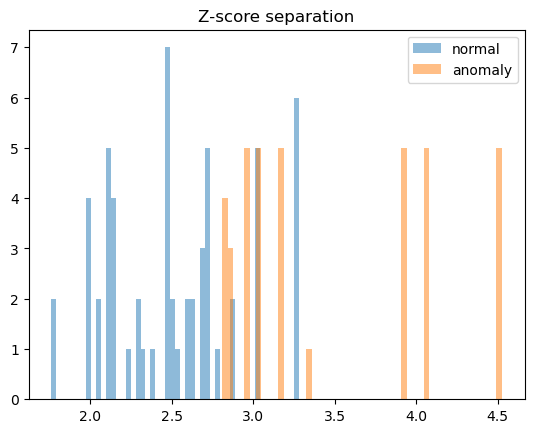

In [61]:
plot_separation(val_scores, y_val_w, "Z-score separation")

<a id="4.2"></a>
<h3 align="left">
  <span style="color: #9C2007;">4.2. Multivariate Gaussian</span>
</h3>

In [62]:
# 1. Prepare data
windowing = Windowing(5, 1)

X_train_w = windowing.transform(X_train)
X_val_w, y_val_w = windowing.transform_with_labels(X_val, y_val)

X_train_model = X_train_w.reshape(X_train_w.shape[0], -1) # or adapt input
X_val_model = X_val_w.reshape(X_val_w.shape[0], -1)

In [64]:
# 2. Model

mu = X_train_model.mean(axis=0)
cov = np.cov(X_train_model, rowvar=False)

# Numerical stability
cov += 1e-6 * np.eye(cov.shape[0])

model = multivariate_normal(
    mean=mu,
    cov=cov,
    allow_singular=False,
)

# Higher = more anomalous
def gaussian_scores(X):
    log_probs = model.logpdf(X)
    return -log_probs

# Validation scores: one score per window
val_scores = gaussian_scores(X_val_model)

# val pred
threshold = np.quantile(gaussian_scores(X_train_model), 0.99)
val_pred = (val_scores > threshold).astype(int)

In [65]:
# 3. Evaluation
gaussian_metrics = evaluator.evaluate(
    scores=val_scores,
    y_true=y_val_w,
    predictions=val_pred,
)

results.append({
    "model": "Gaussian",
    "window_size": 5,
    "stride": 1,
    **gaussian_metrics,
})

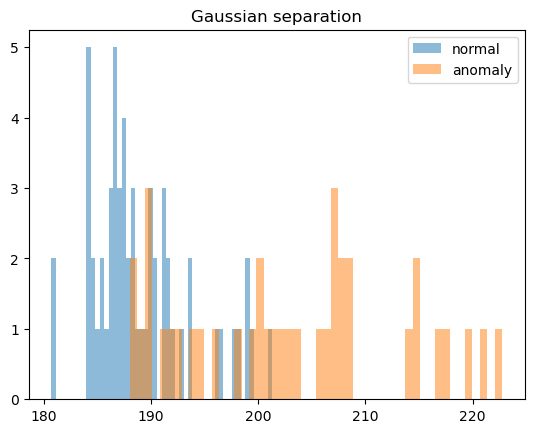

In [67]:
plot_separation(val_scores, y_val_w, "Gaussian separation")

<a id="4.3"></a>
<h3 align="left">
  <span style="color: #9C2007;">4.3. Gaussian Mixtures </span>
</h3>

In [68]:
# 1. Prepare data
windowing = Windowing(5, 1)

X_train_w = windowing.transform(X_train)
X_val_w, y_val_w = windowing.transform_with_labels(X_val, y_val)

X_train_model = X_train_w.reshape(X_train_w.shape[0], -1) # or adapt input
X_val_model = X_val_w.reshape(X_val_w.shape[0], -1)

In [70]:
# 2. Model
gmm = GaussianMixture(
    n_components=4,
    covariance_type="full",
    random_state=42,
)

gmm.fit(X_train_model)

# Higher score = more anomalous
val_scores = -gmm.score_samples(X_val_model)

# preds
threshold = np.quantile(gaussian_scores(X_train_model), 0.99)
val_pred = (val_scores > threshold).astype(int)

In [71]:
# 3. Evaluation
gmm_metrics = evaluator.evaluate(
    scores=val_scores,
    y_true=y_val_w,
    predictions=val_pred,
)

results.append({
    "model": "GMM",
    "window_size": 5,
    "stride": 1,
    **gmm_metrics,
})

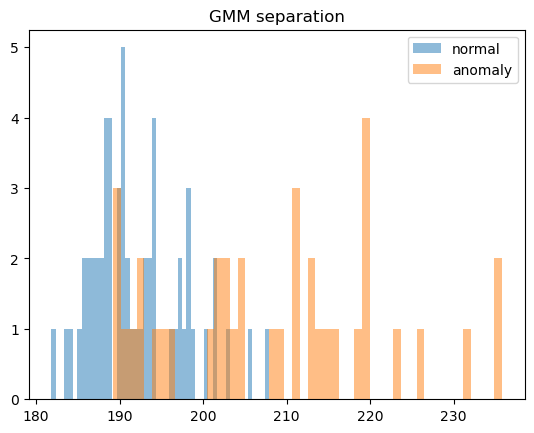

In [72]:
plot_separation(val_scores, y_val_w, "GMM separation")

<a id="5"></a>
<h2 align="center">
  <span style="color: #440E03;">5. Results Analysis </span>
</h2>

In [73]:
results_df = pd.DataFrame(results)
results_df

,model,window_size,stride,mean_score,auc,pr_auc,precision,recall,f1,tn,fp,fn,tp
0,Z-score,5,1,2.897971,0.903811,0.851932,0.702703,0.684211,0.693333,47,11,12,26
1,Gaussian,5,1,194.625703,0.903811,0.888141,1.000000,0.421053,0.592593,58,0,22,16
2,GMM,5,1,198.507296,0.875227,0.867709,0.952381,0.526316,0.677966,57,1,18,20


The three simple statistical baselines provide a useful reference for the subsequent models. All methods show meaningful anomaly-detection capability on the windowed validation data. The z-score baseline achieves the highest AUC (0.904) and F1 score (0.693), while the single Gaussian achieves the highest PR-AUC (0.888) and perfect precision (1.0), at the cost of lower recall (0.421). The GMM does not improve upon the simpler Gaussian model, achieving an AUC of 0.875 and an F1 score of 0.678.

Overall, increasing the complexity of the probabilistic baseline does not provide a clear improvement on this dataset. These models therefore serve primarily as simple reference points for evaluating whether the subsequent autoencoder and sequence-based models provide additional value.